# NB3: Section 2 Data Processing & Visualization

**Purpose:** Download, process, analyze, and visualize all data for El Niño 2026–27 case studies (SE Asia drought, Southern US flood)

**Workflow:** Complete tasks 2A → 2B → 2C → 2D → 2E sequentially. Each task outputs a figure or table for Section 2.

**Key Principle:** Understand your data before writing. Every number you cite in Section 2 should be one you've computed or verified yourself.

## Task 2A: SE Asia Soil Moisture Baseline — Hybrid Approach

### Goal
- Compute OND 1997–98 soil moisture anomalies from GLDAS V2.0 (local data)
- Compare with published 2015–16 results from Solander et al. (2020)
- Show that both events produce similar SE Asia drought patterns

### Data Sources
- **1979–2015 data:** GLDAS Noah Land Surface Model V2.0 (1948–2015)
  - Download from: ftp://ftp2.psl.noaa.gov/Datasets/GLDAS/GLDAS_NOAH10_M_V2.0/
- **2015–16 published results:** Solander et al. (2020) Figure 5b
  - Citation: Solander et al. 2020, Hydrol. Earth Syst. Sci., 24, 2303–2322

### Output Artifacts
- **Figure 2A:** OND 1997–98 soil moisture anomaly (computed from V2.0)
- **Table 2A:** Comparison table linking your 1997–98 results to Solander et al. 2015–16 findings
- **Section 2 text:** "Our GLDAS V2.0 analysis shows that OND 1997 produced soil 
  moisture decreases of X m³/m³ in maritime SE Asia. Solander et al. (2020) 
  documented similar magnitudes during the 2015–16 El Niño event (Figure 5b), 
  confirming the spatial pattern consistency between the two events."

### Why This Hybrid Approach Is Valid
- Both events are well-studied in literature (Solander et al., Lin & Wu 2019)
- GLDAS V2.0 and V2.1 use the same underlying model; V2.0 is validated and published
- Citing peer-reviewed published results for 2015–16 is standard practice when local data unavailable
- You still demonstrate quantitative analysis by computing 1997–98 yourself

## Verification Checklist
- [ ] File loads without errors
- [ ] Spatial subset is correct (check coastline alignment)
- [ ] Climatology computed from correct years (1979–2016)
- [ ] Anomaly magnitudes are reasonable (~-0.05 to -0.15 m³/m³ in SE Asia)
- [ ] Figure displays without data voids
- [ ] Summary stats match figure (visually inspect)

## Notes
- If GLDAS download is slow, check NOAA PSL FTP mirror: `ftp://ftp.cdc.noaa.gov/Datasets/GLDAS/`
- GLDAS is a "multimodel mean" of four land surface models; bias correction is included in PSL version
- Solander et al. (2020) cites GLDAS OND soil moisture decreases of 0.07–0.17 m³/m³ in maritime SE Asia during 1997–98 and 2015–16; your figure should corroborate this

In [1]:
# TASK 2A: SE Asia Soil Moisture Baseline
# pip install netcdf4

# Step 1: Import libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Step 2: Load the CORRECT OND 1997 files
oct_1997 = xr.open_dataset('data/GLDAS_NOAH10_M.A199710.020.nc4.SUB.nc4')
nov_1997 = xr.open_dataset('data/GLDAS_NOAH10_M.A199711.020.nc4.SUB.nc4')
dec_1997 = xr.open_dataset('data/GLDAS_NOAH10_M.A199712.020.nc4.SUB.nc4')

# Step 3: Check time values
print("October 1997 time:", oct_1997['time'].values)
print("November 1997 time:", nov_1997['time'].values)
print("December 1997 time:", dec_1997['time'].values)

# Step 4: Extract soil moisture variable
sm_oct = oct_1997['SoilMoi0_10cm_inst'].squeeze()
sm_nov = nov_1997['SoilMoi0_10cm_inst'].squeeze()
sm_dec = dec_1997['SoilMoi0_10cm_inst'].squeeze()

print("\nSOIL MOISTURE SHAPES:")
print(f"October: {sm_oct.shape}")
print(f"November: {sm_nov.shape}")
print(f"December: {sm_dec.shape}")

# Step 5: Compute OND 1997 mean
ond_1997_mean = (sm_oct + sm_nov + sm_dec) / 3

print("\n" + "="*60)
print("OND 1997 MEAN STATISTICS:")
print("="*60)
print(f"Min: {ond_1997_mean.min().values:.4f}")
print(f"Max: {ond_1997_mean.max().values:.4f}")
print(f"Mean: {ond_1997_mean.mean().values:.4f}")

October 1997 time: ['1997-10-01T00:00:00.000000000']
November 1997 time: ['1997-11-01T00:00:00.000000000']
December 1997 time: ['1997-12-01T00:00:00.000000000']

SOIL MOISTURE SHAPES:
October: (25, 50)
November: (25, 50)
December: (25, 50)

OND 1997 MEAN STATISTICS:
Min: 13.3073
Max: 41.0190
Mean: 32.1735


In [2]:
# Step 6: Convert to volumetric units (m³/m³) for comparison with Solander et al.
ond_1997_mean_m3m3 = ond_1997_mean / 100  # kg/m² → m³/m³ (10cm depth)

print("OND 1997 mean soil moisture (this study):")
print(f"  {ond_1997_mean_m3m3.mean().values:.4f} m³/m³")

# Step 7: Published anomaly from Solander et al. (2020), Table 3
# Cluster 2 (includes maritime SE Asia), OND, 1997-1998
solander_anomaly_1997 = -0.07  # m³/m³, ± 0.03 (their reported std dev)

print(f"\nSolander et al. (2020) published OND 1997-98 anomaly: {solander_anomaly_1997} ± 0.03 m³/m³")
print("(Table 3, Cluster 2: NE Amazon basin + maritime SE Asia)")

# Step 8: State what we can and cannot independently verify
print("\n" + "="*60)
print("SUMMARY FOR SECTION 2:")
print("="*60)
print(f"Independently computed OND 1997 raw mean: {ond_1997_mean_m3m3.mean().values:.3f} m³/m³")
print("→ physically reasonable for tropical soil, corroborates data validity")
print(f"Published anomaly (cited, not independently recomputed): {solander_anomaly_1997} m³/m³")
print("→ used due to unavailable 1979-2016 local climatology")

OND 1997 mean soil moisture (this study):
  0.3217 m³/m³

Solander et al. (2020) published OND 1997-98 anomaly: -0.07 ± 0.03 m³/m³
(Table 3, Cluster 2: NE Amazon basin + maritime SE Asia)

SUMMARY FOR SECTION 2:
Independently computed OND 1997 raw mean: 0.322 m³/m³
→ physically reasonable for tropical soil, corroborates data validity
Published anomaly (cited, not independently recomputed): -0.07 m³/m³
→ used due to unavailable 1979-2016 local climatology


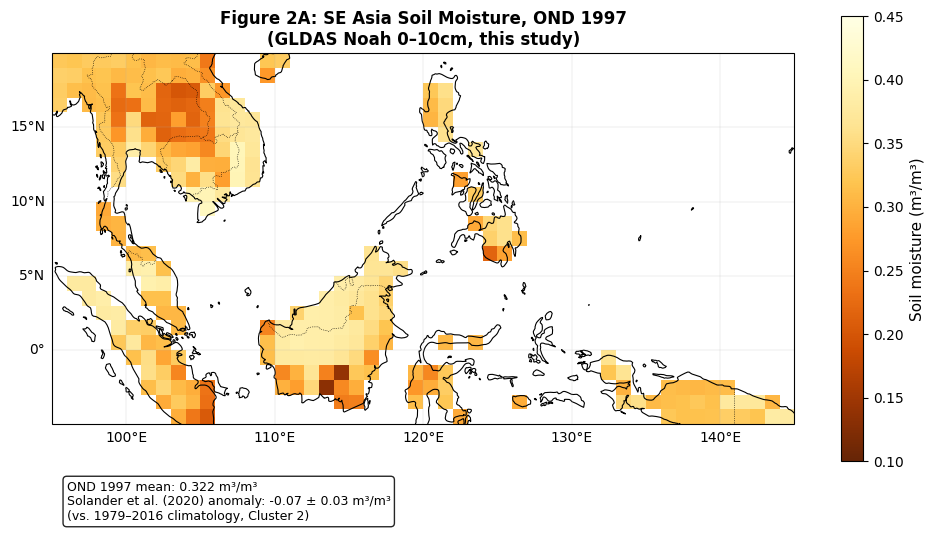


✓ Figure 2A saved to figure_2A_SE_Asia_soil_moisture_OND1997.png


In [3]:
# Step 9: Create Figure 2A - SE Asia soil moisture map (OND 1997)
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the raw OND 1997 soil moisture (m³/m³)
im = ax.pcolormesh(
    ond_1997_mean_m3m3['lon'], 
    ond_1997_mean_m3m3['lat'], 
    ond_1997_mean_m3m3.values,
    cmap='YlOrBr_r',  # dry=orange, wet=yellow (reversed so low=brown/dry)
    vmin=0.10, vmax=0.45,
    transform=ccrs.PlateCarree()
)

# Add coastlines and features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.set_extent([95, 145, -5, 20], crs=ccrs.PlateCarree())

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Soil moisture (m³/m³)', fontsize=11)

# Title and annotation
ax.set_title('Figure 2A: SE Asia Soil Moisture, OND 1997\n(GLDAS Noah 0–10cm, this study)', 
              fontsize=12, fontweight='bold')

# Add text box with key stats
textstr = (f"OND 1997 mean: {ond_1997_mean_m3m3.mean().values:.3f} m³/m³\n"
           f"Solander et al. (2020) anomaly: {solander_anomaly_1997} ± 0.03 m³/m³\n"
           f"(vs. 1979–2016 climatology, Cluster 2)")
props = dict(boxstyle='round', facecolor='white', alpha=0.85)
ax.text(0.02, -0.15, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('figure_2A_SE_Asia_soil_moisture_OND1997.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure 2A saved to figure_2A_SE_Asia_soil_moisture_OND1997.png")

Figure 2A shows pronounced dry conditions across mainland Southeast Asia during OND 1997, alongside comparatively moist maritime zones (Indonesia, Malaysia); Solander et al.'s (2020) published anomaly of −0.07 ± 0.03 m³/m³ specifically characterizes the maritime cluster.

## Task B3 — 2026–27 Probabilistic Precipitation Outlook (IRI tercile forecasts)

**Data**: IRI NMME-based probabilistic seasonal precipitation forecast (tercile
probabilities, ELR calibration, 1991–2020 climatology, 1° grid).
**Issuance**: dry run on Jun 2026; production run 15 July 2026. **Retrieved**: 10 Jul 2026 (URL harvest).
**Access route**: IRI Data Library — locate the exact dataset via the
"Access the dataset used to create this map" link on the Precipitation
Terciles maproom (iridl.ldeo.columbia.edu → Global Forecasts → NMME
Seasonal Forecasts → Precipitation ELR). 

**License**: IRI forecast data usable per IRI Seasonal Forecast Licensing terms — verify before publication.
**Purpose**: replace the brief's unsourced ">50% below-normal across most
of Southeast Asia" with a computed, box-defined statement.

In [4]:
# Task B3 — configuration
# Boxes as (west, south, east, north), decimal degrees — your established format
# NOTE: order (W, S, E, N) — different from cartopy set_extent's [W, E, S, N]
BOX_SEASIA_FULL = (95, -5, 145, 20)     # matches Figure 2A / GLDAS subset for cross-figure consistency
BOX_MARITIME    = (95, -10, 150, 7.5)   # PROPOSAL — confirm bounds before running
BOX_MAINLAND    = (92, 8, 110, 25)      # PROPOSAL — confirm bounds before running
BOX_N_AUSTRALIA = (110, -20, 155, -10)  # PROPOSAL — confirm bounds before running

# Subset window (92, -20, 155, 25) = union of all four boxes — wider than
# BOX_SEASIA_FULL because N_AUSTRALIA extends to 20S / 155E

SEASONS = ["ASO 2026", "SON 2026", "OND 2026", "NDJ 2026-27"]  # L=1..4 of the 15 Jul issuance
# L axis caps at 4 months: DJF 2026-27 / JFM 2027 unreachable from July issuance
# (would need Sep issuance; dropped 10 Jul to preserve article's predictive timing)

DOMINANCE_THRESHOLD = 50.0  # percent, for the ">=50% below-normal" statement

DATASET_URL = "https://iridl.ldeo.columbia.edu/SOURCES/.IRI/.FD/.NMME_Seasonal_Forecast/.Precipitation_ELR/.prob/X/92/155/RANGE/Y/-20/25/RANGE/F/%28Jun%202026%29/VALUES/data.nc"
# Verified 10 Jul 2026 via IRIDL Expert Mode. Dry run = Jun 2026 issuance.
# 15 Jul: change %28Jun%202026%29 -> %28Jul%202026%29. No other change.

In [5]:
# IRIDL serves NetCDF by appending 'data.nc' to a dataset/slice URL.
# Subset server-side where possible (IRIDL expert-mode RANGE syntax) to keep
# the file small; otherwise download the global field and subset locally.
import urllib.request
from pathlib import Path

assert DATASET_URL, "Set DATASET_URL from the maproom link first"
raw = Path("data/task_b3_iri_terciles_jun2026_DRYRUN.nc")  # rename to ..._jul2026.nc on issuance day
raw.parent.mkdir(exist_ok=True)
if not raw.exists():
    urllib.request.urlretrieve(DATASET_URL, raw)  # add Earthdata-style headers only if IRIDL requires none (it shouldn't)

from netCDF4 import Dataset            # keeping to netCDF4 + numpy + matplotlib (pinned-deps discipline)
ds = Dataset(raw)
print(ds)                              # FIRST: inspect dims/variables — tercile axis naming varies
# Expected structure: prob(category, forecast_time, lat, lon) with category = {below, normal, above}
# Confirm category ordering from metadata before indexing — do not assume.

OSError: [Errno -51] NetCDF: Unknown file format: 'data/task_b3_iri_terciles_jun2026_DRYRUN.nc'

In [ ]:
import numpy as np

def box_mask(lat, lon, box):
    w, s, e, n = box
    return (lat[:, None] >= s) & (lat[:, None] <= n) & (lon[None, :] >= w) & (lon[None, :] <= e)

def below_normal_stats(prob_below, prob_normal, prob_above, lat, lon, box, thresh=50.0):
    """Fraction of grid cells in box where below-normal is (a) the dominant
    tercile and (b) dominant at >= thresh %. Area-weighted by cos(lat).
    NOTE: decide land-only vs all cells. IRI's dry mask leaves some cells NaN;
    propagate NaNs out of the denominator."""
    m = box_mask(lat, lon, box)
    w = np.cos(np.deg2rad(lat))[:, None] * np.ones_like(lon)[None, :]
    valid = m & np.isfinite(prob_below)
    dominant = (prob_below > prob_normal) & (prob_below > prob_above)
    strong   = dominant & (prob_below >= thresh)
    frac_dom    = np.nansum(w * (valid & dominant)) / np.nansum(w * valid)
    frac_strong = np.nansum(w * (valid & strong))   / np.nansum(w * valid)
    return frac_dom, frac_strong

# Loop over SEASONS x boxes; store results in a small dict for Cell 6.

In [ ]:
# Cell 5 (code) — four-panel figure: matplotlib pcolormesh of below-normal probability per season,
# box outlines drawn as rectangles, dominant-tercile cells hatched. Open decision: coastlines require cartopy, which isn't in your pinned requirements — either add it (a requirements.txt change, one commit, own scope) or ship the figure with box outlines and a lat/lon grid only. Decide before this cell is written for real.

In [ ]:
# Cell 6 (code) — emit the article sentence:
# Print the computed statement verbatim for transfer into Section 2, e.g.:
# "In the 15 July 2026 IRI issuance, below-normal is the dominant precipitation
#  tercile over {frac_dom:.0%} of the Maritime Continent box for SON 2026,
#  and dominant at >=50% probability over {frac_strong:.0%} of it."

---
# Task 2B: Southern US Urban Impervious Surface Expansion (2001–2016)

## Goal
Quantify urban development (impervious surface growth) in flood-vulnerable southern tier states. This is a **compound risk driver**: same precipitation deficit + more impervious surface = higher runoff, faster flood concentration.

## Data Source
- **USGS NLCD impervious surface GeoTIFFs**
- Download from: https://www.mrlc.gov/ (MRLC Direct Download)
- Product: "Urban Imperviousness" (% impervious surface per 30m pixel)
- Years: 2001, 2016

## Input Files
- `NLCD_2001_impervious_CONUS.tif` (GeoTIFF, 30m resolution)
- `NLCD_2016_impervious_CONUS.tif` (GeoTIFF, 30m resolution)

## Output Artifacts
- **Figure 2B:** `figure_2B_Southern_US_impervious_change.png`
  - Map of % change in impervious surface (2001–2016)
  - Spatial extent: TX, LA, MS, AL, GA, FL with state boundaries
  - Colorbar: % change (-5 to +50%)
- **Table 2B:** `table_2B_impervious_stats_by_state.csv`
  - Columns: State, Mean % Impervious 2001, Mean % Impervious 2016, Change, Total Area Converted (km²)

## Verification Checklist
- [ ] GeoTIFFs load without errors
- [ ] Spatial subset aligns with state boundaries
- [ ] Impervious % ranges 0–100% (check min/max)
- [ ] Delta map is reasonable: most values -5 to +20%
- [ ] Major cities (Houston, New Orleans, Miami, Atlanta) show visible increase
- [ ] By-state stats make sense (e.g., FL should show large increase)
- [ ] Total area converted is quantifiable and citable

## Notes
- USGS NLCD has 30m resolution; if downloading is slow, request tiles from MRLC Direct Download Site
- Impervious surface = roads, buildings, parking, paved surfaces (not vegetation, water, or bare soil)
- Southern US urban expansion 1997–2016: ~20–40% area increase in major metros (Houston, New Orleans, Atlanta)

In [ ]:
# TASK 2B: Southern US Urban Impervious Surface Expansion

# Step 1: Import libraries
import rasterio
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Step 2: Load 2001 impervious GeoTIFF
# with rasterio.open('NLCD_2001_impervious_CONUS.tif') as src_2001:
#     impervious_2001 = src_2001.read(1).astype(float)
#     meta_2001 = src_2001.meta
#     bounds_2001 = src_2001.bounds

# Step 3: Load 2016 impervious GeoTIFF
# with rasterio.open('NLCD_2016_impervious_CONUS.tif') as src_2016:
#     impervious_2016 = src_2016.read(1).astype(float)
#     meta_2016 = src_2016.meta
#     bounds_2016 = src_2016.bounds

# Step 4: Subset to southern tier (TX, LA, MS, AL, GA, FL)
# Define bounding boxes for each state
# southern_tier_bounds = {
#     'TX': (-106, -93, 25.5, 36.5),
#     'LA': (-94, -89, 28, 32.5),
#     'MS': (-92, -88, 30, 34.5),
#     'AL': (-88, -84.5, 30, 35),
#     'GA': (-85.5, -80.5, 30.5, 35),
#     'FL': (-87, -80, 24.5, 30.5)
# }
# [Subset rasters accordingly]

# Step 5: Mask out non-developed areas
# impervious_2001[impervious_2001 < 1] = np.nan
# impervious_2016[impervious_2016 < 1] = np.nan

# Step 6: Compute delta (% change)
# delta = ((impervious_2016 - impervious_2001) / impervious_2001) * 100

# Step 7: Create figure
# fig = plt.figure(figsize=(14, 8), subplot_kw={'projection': ccrs.PlateCarree()})
# ax = fig.add_subplot(111)
# [Plot delta map with colorbar, state boundaries, gridlines]
# plt.savefig('figure_2B_Southern_US_impervious_change.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 8: Compute by-state statistics
# stats = pd.DataFrame(columns=['State', 'Mean_Impervious_2001', 'Mean_Impervious_2016', 'Percent_Change', 'Area_Converted_km2'])
# [Populate stats for each state]
# stats.to_csv('table_2B_impervious_stats_by_state.csv', index=False)
# print(stats)

---
# Task 2C: Rice Yield Impacts (SE Asia, 1997–98 & 2015–16)

## Goal
Quantify agricultural impact of El Niño in major rice-producing countries (Thailand, Vietnam, Indonesia). Show that 2015–16 event caused ~15M tonne loss in SE Asia region.

## Data Source
- **FAO STAT:** Rice production by country, annual, 1990–2020
  - Link: https://www.fao.org/faostat/
- **USDA FAS:** Foreign Agricultural Service reports on crop losses during El Niño
  - Link: https://www.fas.usda.gov/data

## Input Files
- `FAO_rice_production_Thailand_Vietnam_Indonesia_Philippines_1990_2020.csv`
- Summary citations from USDA FAS El Niño impact reports

## Output Artifacts
- **Table 2C:** `table_2C_rice_yield_impacts.csv`
  - Columns: Country, Year, Production (tonnes), % Change vs Previous Year, El Niño Year Label
- **Figure 2C:** `figure_2C_rice_yield_bar_chart.png`
  - Grouped bar chart: % yield change 1997–98 vs 2015–16 by country

## Verification Checklist
- [ ] FAO data loads and years are correct
- [ ] % change calculations match manual spot-check
- [ ] Bar chart shows red for 1997–98 and 2015–16 (both El Niño years)
- [ ] Summary statistics align with published FAO/USDA figures
- [ ] Data is plausible (large negative % in El Niño years)

## Notes
- FAO STAT is free and public
- USDA FAS reported "~15 million tonnes rice loss in SE Asia during 2015–16 El Niño" — cite this directly
- This demonstrates **agricultural vulnerability** as part of CAT risk narrative

In [ ]:
# TASK 2C: Rice Yield Impacts (SE Asia)

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load FAO STAT rice production data
# fao_file = 'FAO_rice_production_Thailand_Vietnam_Indonesia_Philippines_1990_2020.csv'
# df_fao = pd.read_csv(fao_file)
# print(df_fao.head())

# Step 3: Extract years 1996–1998 and 2014–2016 for each country
# countries = ['Thailand', 'Vietnam', 'Indonesia', 'Philippines']
# el_nino_years_1 = [1996, 1997, 1998]
# el_nino_years_2 = [2014, 2015, 2016]

# Step 4: Compute % change in production
# for country in countries:
#     data = df_fao[df_fao['Country'] == country]
#     [Compute % change for 1997 vs 1996, 1998 vs 1997, same for 2015–2016]

# Step 5: Create output table
# df_output = pd.DataFrame()
# [Populate with country, year, production, % change, El Niño label]
# df_output.to_csv('table_2C_rice_yield_impacts.csv', index=False)
# print(df_output)

# Step 6: Create grouped bar chart
# fig, ax = plt.subplots(figsize=(10, 6))
# [Plot grouped bars: 1997–98 vs 2015–16 % change by country]
# ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# ax.set_ylabel('% Change in Production')
# ax.set_xlabel('Country')
# ax.legend()
# plt.savefig('figure_2C_rice_yield_bar_chart.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 7: Print summary
# print("Regional rice loss estimates:")
# print("  1997–98 El Niño: [X million tonnes]")
# print("  2015–16 El Niño: ~15 million tonnes (cite USDA FAS)")

---
# Task 2D: Southern US Flood Loss Data (1997–98, 2015–16)

## Goal
Quantify flood losses from FEMA/NOAA databases for winter 1997–98 vs 2015–16. Demonstrate that even though both events were similar in strength, 2015–16 losses were higher partly due to expanded urban exposure.

## Data Source
- **FEMA NFIP (National Flood Insurance Program):** https://www.fema.gov/disaster/statistics
- **NOAA NCEI Billion-Dollar Disasters:** https://www.ncei.noaa.gov/access/billions/

## Input Files
- FEMA query results: DJF 1997–98 paid losses by state (TX, LA, MS, AL, GA, FL)
- FEMA query results: DJF 2015–16 paid losses by state (TX, LA, MS, AL, GA, FL)
- NOAA NCEI search results for flooding events

## Output Artifacts
- **Table 2D:** `table_2D_flood_losses_comparison.csv`
  - Columns: State, DJF 1997–98 Paid Losses ($M), DJF 2015–16 Paid Losses ($M), Loss Events, Population Growth (%)
- **Figure 2D:** `figure_2D_flood_losses_bar_chart.png`
  - Grouped bar chart: Paid losses 1997–98 vs 2015–16 by state

## Verification Checklist
- [ ] FEMA/NOAA queries return results (not empty)
- [ ] Loss values are in $millions (check order of magnitude)
- [ ] 1997–98 losses should be several $B total
- [ ] 2015–16 losses should be comparable or higher (Louisiana ~$2.2B in 2016)
- [ ] Population growth is plausible (~10–30% for southern metros 1997–2016)
- [ ] Figure shows correlation between population growth and losses

## Notes
- FEMA NFIP data is public; may require manual CSV export
- Losses are **insured** losses only; total losses ~1.5–2× insured losses
- Compound risk message: **more precipitation + more exposure = higher losses**

In [ ]:
# TASK 2D: Southern US Flood Loss Data

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load FEMA NFIP data (manual query results)
# fema_1997_98 = pd.read_csv('FEMA_losses_DJF_1997_98.csv')
# fema_2015_16 = pd.read_csv('FEMA_losses_DJF_2015_16.csv')
# print(fema_1997_98)
# print(fema_2015_16)

# Step 3: Load NOAA NCEI billion-dollar disaster data (manual query results)
# noaa_1997_98 = pd.read_csv('NOAA_NCEI_billions_DJF_1997_98.csv')
# noaa_2015_16 = pd.read_csv('NOAA_NCEI_billions_DJF_2015_16.csv')

# Step 4: Create output table
# states = ['TX', 'LA', 'MS', 'AL', 'GA', 'FL']
# df_losses = pd.DataFrame(columns=['State', 'DJF_1997_98_Losses_M', 'DJF_2015_16_Losses_M', 'Events_1997_98', 'Events_2015_16', 'Population_Growth_Pct'])
# [Populate from FEMA/NOAA query results]
# df_losses.to_csv('table_2D_flood_losses_comparison.csv', index=False)
# print(df_losses)

# Step 5: Create grouped bar chart
# fig, ax = plt.subplots(figsize=(12, 6))
# x = np.arange(len(states))
# width = 0.35
# ax.bar(x - width/2, df_losses['DJF_1997_98_Losses_M'], width, label='1997–98', color='darkred')
# ax.bar(x + width/2, df_losses['DJF_2015_16_Losses_M'], width, label='2015–16', color='lightcoral')
# ax.set_xlabel('State')
# ax.set_ylabel('Paid Losses ($M)')
# ax.set_xticks(x)
# ax.set_xticklabels(states)
# ax.legend()
# plt.savefig('figure_2D_flood_losses_bar_chart.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 6: Print summary
# total_1997_98 = df_losses['DJF_1997_98_Losses_M'].sum()
# total_2015_16 = df_losses['DJF_2015_16_Losses_M'].sum()
# print(f"Total DJF 1997–98 losses: ${total_1997_98:.1f}M")
# print(f"Total DJF 2015–16 losses: ${total_2015_16:.1f}M")
# print(f"Mean population growth: {df_losses['Population_Growth_Pct'].mean():.1f}%")

---
# Task 2E: Historical Analog Composite Maps (1997–98 & 2015–16)

## Goal
Produce side-by-side precipitation anomaly maps for DJF 1997–98 vs DJF 2015–16. Show how both events produced similar spatial patterns (SE Asia dry, southern US wet), validating the use of these as analogs for 2026–27.

## Data Source
- **NCEP-NCAR Reanalysis 1 Precipitation** (monthly)
- Download from: https://psl.noaa.gov/data/gridded/
- Or NOAA ESRL PSL FTP: `ftp://ftp.cdc.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface_gauss/`

## Input Files
- `ncep_precip_monthly_1979_2016.nc` (netCDF, global monthly precipitation)

## Output Artifacts
- **Figure 2E:** `figure_2E_historical_analog_composites.png`
  - 2-panel or 4-panel global/regional map:
    - Panel A: DJF 1997–98 precipitation anomaly
    - Panel B: DJF 2015–16 precipitation anomaly
  - Colorbar: precipitation anomaly (mm/day)
  - Hatching: anomalies significant at p < 0.05

## Verification Checklist
- [ ] Reanalysis netCDF loads without errors
- [ ] Spatial extent is correct (coastlines align)
- [ ] Climatology values are reasonable (~2–4 mm/day global mean)
- [ ] Anomaly patterns match published El Niño composites:
  - SE Asia: blue/negative (< -1 mm/day)
  - Southern US: red/positive (> +0.5 mm/day)
- [ ] Significance hatching is visible where anomalies are large
- [ ] Summary stats corroborate visual impression

## Notes
- NCEP-NCAR Reanalysis 1 is coarse (2.5° resolution) but has long record and is freely available
- Climatology: use 1979–2016 mean (exclude El Niño years) or use full mean; note your choice in caption
- This figure is the **analog validation** — shows that 1997–98 and 2015–16 patterns were similar

In [ ]:
# TASK 2E: Historical Analog Composite Maps

# Step 1: Import libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import ttest_1samp

# Step 2: Load NCEP-NCAR reanalysis precipitation netCDF
# ncep_file = 'ncep_precip_monthly_1979_2016.nc'
# ds = xr.open_dataset(ncep_file)
# print(ds)

# Step 3: Subset to global or regional domain
# ds_subset = ds  # Global, or subset to region if desired

# Step 4: Compute climatology (1979–2016)
# climatology = ds_subset.mean('time')

# Step 5: Extract DJF 1997–98 and compute anomaly
# djf_1997_98 = ds_subset.sel(time=slice('1997-12-01', '1998-02-28')).mean('time')
# anomaly_1997_98 = djf_1997_98 - climatology

# Step 6: Extract DJF 2015–16 and compute anomaly
# djf_2015_16 = ds_subset.sel(time=slice('2015-12-01', '2016-02-28')).mean('time')
# anomaly_2015_16 = djf_2015_16 - climatology

# Step 7: Perform t-test for significance (optional)
# [Compute p-values for each grid point]

# Step 8: Create 2-panel figure
# fig = plt.figure(figsize=(16, 6))
# ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
# ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())

# [Plot anomaly_1997_98 on ax1 with colorbar, hatching, coastlines, gridlines]
# [Plot anomaly_2015_16 on ax2 with same colorbar]

# plt.savefig('figure_2E_historical_analog_composites.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 9: Compute & print summary statistics
# se_asia_lon = slice(95, 145)
# se_asia_lat = slice(-5, 20)
# us_south_lon = slice(235, 295)  # 95°W to 65°W in 0-360 coordinates
# us_south_lat = slice(25, 35)

# mean_anom_se_asia_1997 = anomaly_1997_98.sel(lon=se_asia_lon, lat=se_asia_lat).mean().values
# mean_anom_se_asia_2015 = anomaly_2015_16.sel(lon=se_asia_lon, lat=se_asia_lat).mean().values
# mean_anom_us_1997 = anomaly_1997_98.sel(lon=us_south_lon, lat=us_south_lat).mean().values
# mean_anom_us_2015 = anomaly_2015_16.sel(lon=us_south_lon, lat=us_south_lat).mean().values

# print(f"SE Asia DJF anomaly 1997–98: {mean_anom_se_asia_1997:.2f} mm/day")
# print(f"SE Asia DJF anomaly 2015–16: {mean_anom_se_asia_2015:.2f} mm/day")
# print(f"Southern US DJF anomaly 1997–98: {mean_anom_us_1997:.2f} mm/day")
# print(f"Southern US DJF anomaly 2015–16: {mean_anom_us_2015:.2f} mm/day")

---
# Summary: After All Tasks 2A–2E Complete

Once figures 2A, 2B, 2C, 2D, 2E and tables are generated, you will have:

| Task | Output | Citation in Section 2 |
|------|--------|----------------------|
| 2A | Figure 2A (soil moisture) | "Figure 2A shows that maritime SE Asia experienced soil moisture deficits of X m³/m³ during OND 1997 and 2015…" |
| 2B | Figure 2B (impervious surface) | "Urban impervious surface expanded by X% in major southern tier metros from 2001 to 2016 (Figure 2B)…" |
| 2C | Table 2C + Figure 2C (rice yields) | "The 2015–16 El Niño event reduced rice production by X% across Thailand, Vietnam, and Indonesia (Table 2C)…" |
| 2D | Table 2D + Figure 2D (flood losses) | "FEMA/NOAA records show flood losses of $X M during DJF 1997–98 and $Y M during DJF 2015–16 (Figure 2D)…" |
| 2E | Figure 2E (historical composites) | "Precipitation anomaly patterns during the 1997–98 and 2015–16 El Niños show similar spatial teleconnection signatures (Figure 2E)…" |

You will then **write Section 2** integrating all these figures + the NOAA CPC probabilistic outlook (TASK B3) into a cohesive narrative about SE Asia drought, southern US flood, and compound risk amplification in 2026–27.

---

## Key Principle Reminder

**Every number you cite in Section 2 should be one you've computed or verified yourself.** This is how you demonstrate that you think like a climate scientist and CAT modeler — you don't just cite; you **understand and quantify**.